In [1]:
#import-libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score

In [2]:
#load-dataset
data=load_breast_cancer()
df=pd.DataFrame(data.data,columns=data.feature_names)
df["target"]=data.target
df.head()
df.shape

#EDA-checking-data-is-balanced-or-imbalaned
df["target"].value_counts()

target
1    357
0    212
Name: count, dtype: int64

In [3]:
#features-target
x=df.drop("target",axis=1)
y=df["target"]

#split-data
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

#train-model
rf=RandomForestClassifier(n_estimators=200, 
                          max_depth=3, 
                          max_features='sqrt',
                          min_samples_split=5, 
                          min_samples_leaf=2, 
                          bootstrap=True, 
                          oob_score=True,
                          random_state=42)
rf.fit(x_train,y_train)

#predict
y_pred=rf.predict(x_test)
y_pred_train=rf.predict(x_train)

#evaluate
print("train accuracy: ",accuracy_score(y_train,y_pred_train))
print("test accuracy: ",accuracy_score(y_test,y_pred))
print("classification report\n", classification_report(y_test,y_pred))
print("confusion matrix\n",confusion_matrix(y_test,y_pred))
print("OOB score:",rf.oob_score_)

train accuracy:  0.9736263736263736
test accuracy:  0.9649122807017544
classification report
               precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

confusion matrix
 [[40  3]
 [ 1 70]]
OOB score: 0.9472527472527472


Feature importance Axes(0.125,0.11;0.775x0.77)


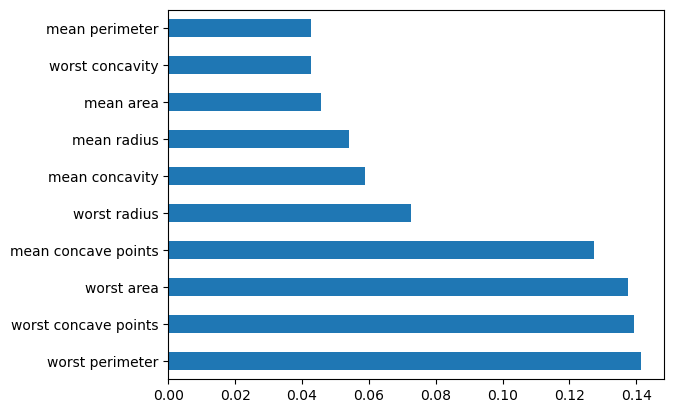

In [10]:
#feature-importance
feature_importance=pd.Series(rf.feature_importances_, index=data.feature_names)
feature_importance=feature_importance.sort_values(ascending=False)
print("Feature importance",feature_importance.head(10).plot(kind="barh"))

In [5]:
params={
    "n_estimators":[100,200],
    "max_features":['sqrt','log2'],
    "max_depth":[5,10,None],
}
grid=GridSearchCV(
    RandomForestClassifier(random_state=42),
    params,
    cv=5,
    n_jobs=-1)
grid.fit(x_train,y_train)
print("best params",grid.best_params_)
print("best score",grid.best_score_)

best params {'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 200}
best score 0.9626373626373625


In [6]:
#AUC_score
y_prob=rf.predict_proba(x_test)[:,1] # roc_auc need probability of positive class. if uses negative classes, AUC become incorrect.
fpr,tpr,thresholds=roc_curve(y_test,y_prob)
auc_score=roc_auc_score(y_test,y_prob)
print("AUC score",auc_score)

AUC score 0.9970520799213888


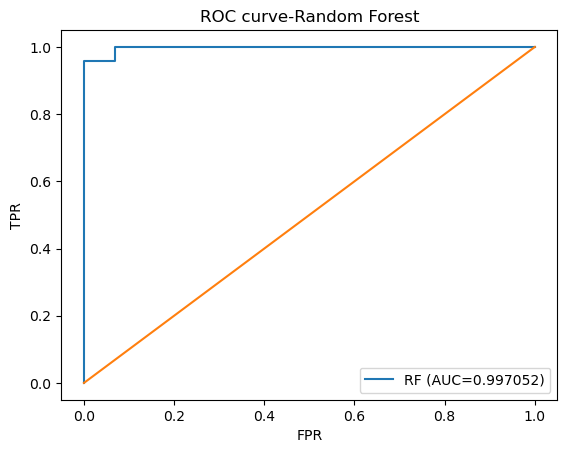

In [7]:
#plot-roc-auc-curve
plt.figure()
plt.plot(fpr,tpr,label=f"RF (AUC={auc_score:3f})")
plt.plot([0,1],[0,1])
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC curve-Random Forest")
plt.legend()
plt.savefig("Random Forest ROC curve")
plt.show()